In [ ]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

In [ ]:
def roll_dice(n=0):
    if n == 0:
        return np.random.ranint(1,7) + np.random.ranint(1,7)
    return np.random.ranint(1,7, size=n) + np.random.ranint(1,7, size=n)

In [ ]:
def p1_stand_win_chance(x):
    # Give p1 score 0<=x<=20 it finds the chance of p1 winnning, tieing, losing
    rolls = np.array([i for i in range(2, 13)])
    roll_probs = np.array([1/36, 2/36, 3/36, 4/36, 5/36, 6/36, 5/36, 4/36, 3/36, 2/36, 1/36])
    chances = {1:0, 0:0, -1:0} # 1 is win, 0 is tie, -1 is loss
    cur = {0: 1}

    while cur:
        d = defaultdict(float)
        for r, p in cur.items():
            next = r + rolls
            next[next > 21] = -3
            next[next > x] = -1
            next[next == x] = -2
            for i in range(len(next)):
                val = next[i]
                if val == -1:
                    chances[-1] += roll_probs[i] * p
                elif val == -2:
                    chances[0] += roll_probs[i] * p
                elif val == -3:
                    chances[1] += roll_probs[i] * p
                else:
                    d[val] += roll_probs[i] * p
        cur = d
    return chances

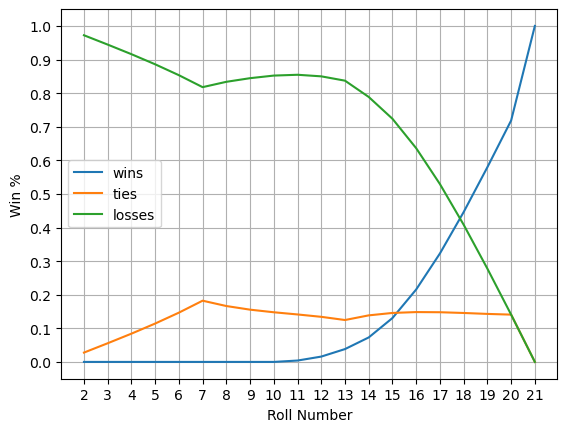

In [24]:
rolls = [i for i in range(2, 21)]
wins = []
ties = []
losses = []

for roll in rolls:
    chances = p1_win_chance(roll)
    wins.append(chances[1])
    ties.append(chances[0])
    losses.append(chances[-1])
    # print(roll, wins[-1], ties[-1], losses[-1])
wins.append(1)
ties.append(0)
losses.append(0)

plt.plot(rolls + [21], wins, label="wins")
plt.plot(rolls + [21], ties, label="ties")
plt.plot(rolls + [21], losses, label="losses")
plt.legend()
plt.grid()
plt.xlabel("Roll Number")
plt.ylabel("Win %")
plt.xticks(rolls + [21])
plt.yticks([i/10 for i in range(0, 11)])
plt.show()

In [25]:
def find_win(x, roller=False, stand=False, not_lose=False):

    if x > 21:
        return {1:0, 0:0, -1:1}

    # Get some inital values
    if roller is False:
        roller = {}
    rolls = np.array([i for i in range(2, 13)])
    roll_probs = np.array([1/36, 2/36, 3/36, 4/36, 5/36, 6/36, 5/36, 4/36, 3/36, 2/36, 1/36])
    rollst = [i for i in range(2, 21)]
    if stand is False:
        stand = {}
        for roll in rollst:
            chances = p1_win_chance(roll)
            stand[roll] = chances
        stand[21] = {1:1, 0:0, -1:0}


    
    # First check stand
    if x == 0:
        s_probs = {1:0, 0:0, -1:1}
    else:
        s_probs = stand[x]


    # Then check roll
    r_probs = {1:0, 0:0, -1:0}
    for i in range(len(rolls)):
        r, p = rolls[i] + x, roll_probs[i]
        if r not in roller.keys():
            chances = find_win(r, roller=roller, stand=stand, not_lose=not_lose)
            roller[r] = chances
        else:
            chances = roller[r]
        r_probs[1] += p * chances[1]
        r_probs[0] += p * chances[0]
        r_probs[-1] += p * chances[-1]

    if not_lose:
        if s_probs[1] + s_probs[0] > r_probs[1] + r_probs[0]:
            return s_probs
        return r_probs
    if s_probs[1] > r_probs[1]:
        return s_probs
    return r_probs
                

print(find_win(0)) 
print(find_win(0, not_lose=True)) 

{1: np.float64(0.40184464217375515), 0: np.float64(0.0995006589395298), -1: np.float64(0.4986546988867151)}
{1: np.float64(0.40184464217375515), 0: np.float64(0.0995006589395298), -1: np.float64(0.4986546988867151)}


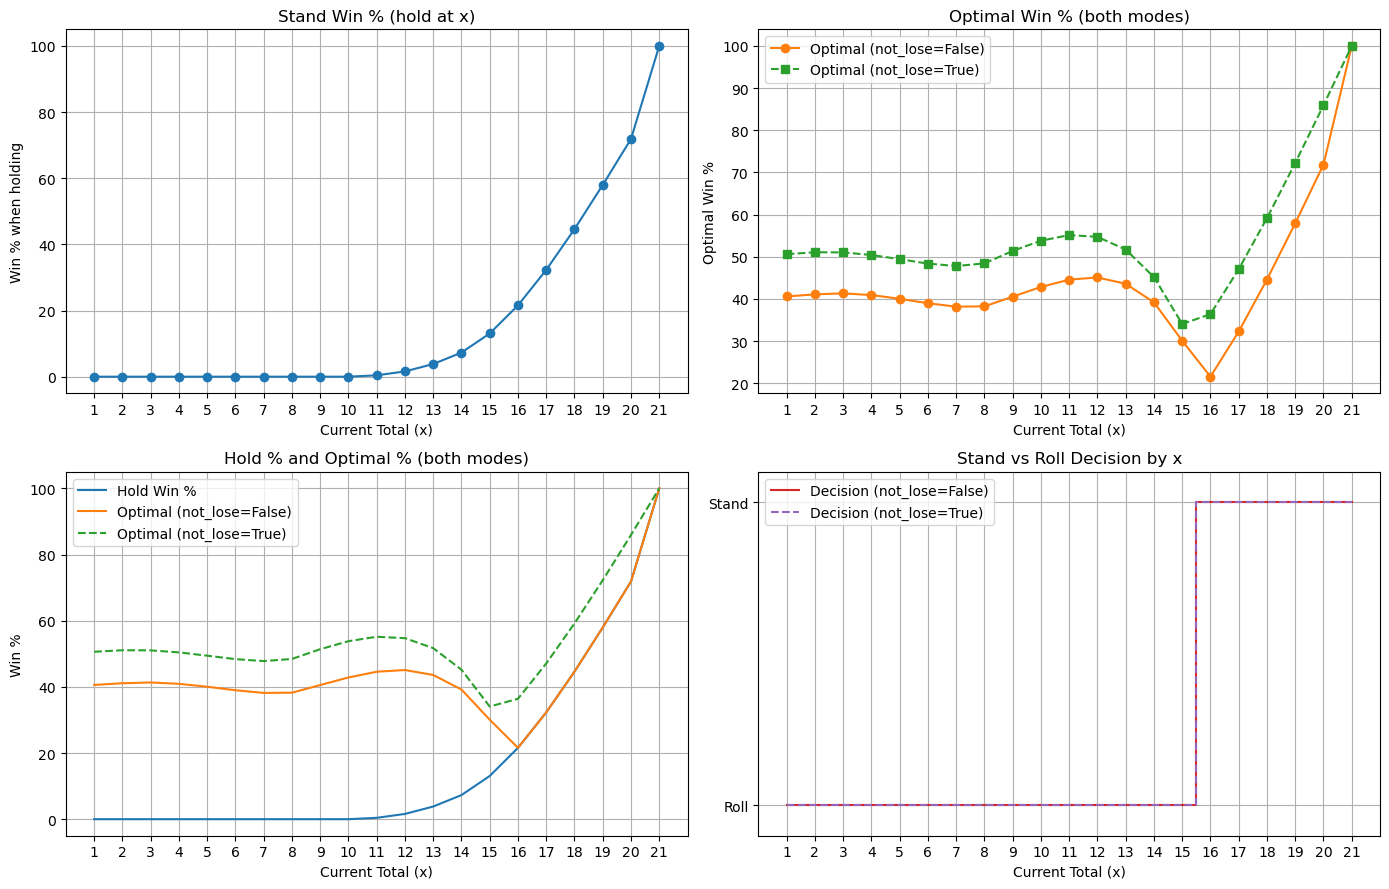

In [26]:
# Plotting: 4 subplots showing stand %, optimal win % (find_win), combined, and stand/roll decision
import numpy as np
import matplotlib.pyplot as plt

# Prepare constants
rolls = np.arange(2, 13)
roll_probs = np.array([1/36, 2/36, 3/36, 4/36, 5/36, 6/36, 5/36, 4/36, 3/36, 2/36, 1/36])

# Precompute stand (holding) chances for 0..21
stand_cache = {0: {1:0, 0:0, -1:1}, 21: {1:1, 0:0, -1:0}}
for x in range(1, 21):
    stand_cache[x] = p1_win_chance(x)

def compute_for_mode(not_lose=False):
    # memoization for recursive roll outcomes (matches find_win recursion)
    memo = {}

    def compute_choice(x):
        if x > 21:
            return {1:0, 0:0, -1:1}
        if x in memo:
            return memo[x]
        s_probs = stand_cache.get(x, p1_win_chance(x))
        # compute roll expectations
        r_probs = {1:0, 0:0, -1:0}
        for i, p in enumerate(roll_probs):
            r = x + rolls[i]
            ch = compute_choice(r)
            r_probs[1] += p * ch[1]
            r_probs[0] += p * ch[0]
            r_probs[-1] += p * ch[-1]
        # decision per mode
        if not_lose:
            chosen = s_probs if (s_probs[1] + s_probs[0]) > (r_probs[1] + r_probs[0]) else r_probs
        else:
            chosen = s_probs if s_probs[1] > r_probs[1] else r_probs
        memo[x] = chosen
        return chosen

    x_vals = list(range(1, 22))
    stand_wins = [stand_cache[x][1] for x in x_vals]
    optimal_wins = []
    decisions = []
    # For computing r_probs (roll expectation using the "policy" for deeper states), reuse compute_choice
    for x in x_vals:
        s = stand_cache[x]
        # build r_probs explicitly
        r_probs = {1:0, 0:0, -1:0}
        for i, p in enumerate(roll_probs):
            r = x + rolls[i]
            ch = compute_choice(r)
            r_probs[1] += p * ch[1]
            r_probs[0] += p * ch[0]
            r_probs[-1] += p * ch[-1]
        if not_lose:
            best_val = max(s[1] + s[0], r_probs[1] + r_probs[0])
            decision = 1 if (s[1] + s[0]) > (r_probs[1] + r_probs[0]) else 0
        else:
            best_val = max(s[1], r_probs[1])
            decision = 1 if s[1] > r_probs[1] else 0
        optimal_wins.append(best_val)
        decisions.append(decision)

    return x_vals, stand_wins, optimal_wins, decisions

# Compute both modes
xs_f, stand_wins_f, optimal_f, decisions_f = compute_for_mode(not_lose=False)
xs_t, stand_wins_t, optimal_t, decisions_t = compute_for_mode(not_lose=True)

# Plotting 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

# Subplot 1: percent chances of standing at each number
ax = axs[0,0]
ax.plot(xs_f, np.array(stand_wins_f)*100, marker='o')
ax.set_title('Stand Win % (hold at x)')
ax.set_xlabel('Current Total (x)')
ax.set_ylabel('Win % when holding')
ax.set_xticks(xs_f)
ax.grid(True)

# Subplot 2: optimal percents using find_win (both modes)
ax = axs[0,1]
ax.plot(xs_f, np.array(optimal_f)*100, marker='o', color='C1', label='Optimal (not_lose=False)')
ax.plot(xs_t, np.array(optimal_t)*100, marker='s', color='C2', linestyle='--', label='Optimal (not_lose=True)')
ax.set_title('Optimal Win % (both modes)')
ax.set_xlabel('Current Total (x)')
ax.set_ylabel('Optimal Win %')
ax.set_xticks(xs_f)
ax.legend()
ax.grid(True)

# Subplot 3: show percent-hold and optimal together for both modes
ax = axs[1,0]
ax.plot(xs_f, np.array(stand_wins_f)*100, label='Hold Win %', color='C0')
ax.plot(xs_f, np.array(optimal_f)*100, label='Optimal (not_lose=False)', color='C1')
ax.plot(xs_t, np.array(optimal_t)*100, label='Optimal (not_lose=True)', color='C2', linestyle='--')
ax.set_title('Hold % and Optimal % (both modes)')
ax.set_xlabel('Current Total (x)')
ax.set_ylabel('Win %')
ax.set_xticks(xs_f)
ax.legend()
ax.grid(True)

# Subplot 4: stand (1) or roll (0) for both modes
ax = axs[1,1]
ax.step(xs_f, decisions_f, where='mid', label='Decision (not_lose=False)', color='C3')
ax.step(xs_t, decisions_t, where='mid', label='Decision (not_lose=True)', color='C4', linestyle='--')
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0,1])
ax.set_yticklabels(['Roll','Stand'])
ax.set_title('Stand vs Roll Decision by x')
ax.set_xlabel('Current Total (x)')
ax.set_xticks(xs_f)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()
